<a href="https://colab.research.google.com/github/priyankadhas5/Computer-Engineering-Study-Material/blob/Essential-AI-ML-Labs/Pr1_EssAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import networkx as nx

# =====================================================================
# 1. OBJECT RELATIONSHIPS (OOP Inheritance)
# =====================================================================
class Animal:
    def __init__(self, name: str):
        self.name = name
        self.is_extinct = False  # Base property

class Bird(Animal):  # "Is-A" Relationship (Inheritance)
    def __init__(self, name: str):
        super().__init__(name)
        self.has_feathers = True

class Canary(Bird):  # Subclass inheriting from Bird
    def __init__(self, name: str):
        super().__init__(name)
        self.color = "yellow"

# Create a concrete instance
tweety = Canary("Tweety")


# =====================================================================
# 2. SEMANTIC NETWORK (Knowledge Representation Graph)
# =====================================================================
# We use a Directed Graph to map out concepts and their relationships
semantic_net = nx.DiGraph()

# Add relationships (Edges with labels)
semantic_net.add_edge("Canary", "Bird", relation="is_a")
semantic_net.add_edge("Bird", "Fly", relation="can")
semantic_net.add_edge("Bird", "Feathers", relation="has")

def infer_property(start_node: str, property_node: str, relation_type: str) -> bool:
    """Uses the semantic network to infer inherited traits via a path."""
    try:
        # Check if there is a path from the starting concept to the target property
        path = nx.shortest_path(semantic_net, source=start_node, target=property_node)
        # Verify if the relationship type aligns in our simple chain
        return len(path) > 1
    except nx.NetworkXNoPath:
        return False

# AI infers that Tweety can fly through inheritance in the Semantic Network
can_tweety_fly = infer_property("Canary", "Fly", "can")


# =====================================================================
# 3. BOOLEAN ALGEBRA (Logical Reasoning)
# =====================================================================
# Inputs derived from our Object and Semantic Network
is_canary = isinstance(tweety, Canary)
has_feathers = tweety.has_feathers
is_not_extinct = not tweety.is_extinct
can_fly = can_tweety_fly

# Boolean Equation: (Is a Canary AND Has Feathers AND Can Fly) AND NOT Extinct
ai_decision = (is_canary and has_feathers and can_fly) and is_not_extinct


# =====================================================================
# OUTPUT THE RESULTS
# =====================================================================
print(f"--- Object Relationships ---")
print(f"Is {tweety.name} a Canary? {is_canary}")
print(f"Does {tweety.name} inherit feathers from Bird class? {has_feathers}")

print(f"\n--- Semantic Network Inference ---")
print(f"Can a Canary fly? (Inferred from Bird): {can_tweety_fly}")

print(f"\n--- Boolean Algebra Evaluation ---")
print(f"Formula: (Canary ^ Feathers ^ Can_Fly) ^ ~Extinct")
print(f"AI Decision (Valid Target Animal): {ai_decision}")


--- Object Relationships ---
Is Tweety a Canary? True
Does Tweety inherit feathers from Bird class? True

--- Semantic Network Inference ---
Can a Canary fly? (Inferred from Bird): True

--- Boolean Algebra Evaluation ---
Formula: (Canary ^ Feathers ^ Can_Fly) ^ ~Extinct
AI Decision (Valid Target Animal): True


In [3]:
!pip install networkx matplotlib


Analyzing patient: Rahul (Age: 20)
Symptoms entered: ['fever', 'cough']
Semantic Network matches: {'Cold', 'Infection', 'Flu'}

AI System Decision: Influenza (Flu)

[Visualizer] Displaying Semantic Network window... Close window to continue script execution.


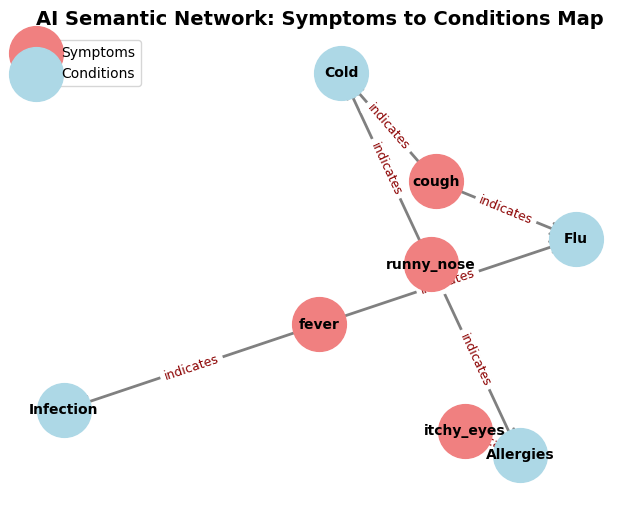

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# =====================================================================
# 1. OBJECT RELATIONSHIPS (OOP Principles)
# =====================================================================
class Patient:
    """Represents the object we are analyzing."""
    def __init__(self, name, age):
        self.name = name
        self.age = age
        self.symptoms = []  # Will hold a list of symptom strings

# =====================================================================
# 2. SEMANTIC NETWORK (Graph-Based Knowledge Base)
# =====================================================================
# Initialize a NetworkX Directed Graph
semantic_net = nx.DiGraph()

# Define edge relationships: (Source Node, Target Node, Relationship Edge Label)
relationships = [
    ("fever", "Flu", "indicates"),
    ("fever", "Infection", "indicates"),
    ("cough", "Flu", "indicates"),
    ("cough", "Cold", "indicates"),
    ("runny_nose", "Cold", "indicates"),
    ("runny_nose", "Allergies", "indicates"),
    ("itchy_eyes", "Allergies", "indicates")
]

# Populate the semantic network graph
for source, target, rel in relationships:
    semantic_net.add_edge(source, target, relation=rel)

def infer_possible_conditions(patient_symptoms):
    """Traverses the network graph to find connected condition nodes."""
    possible_matches = []
    for symptom in patient_symptoms:
        if semantic_net.has_node(symptom):
            # Fetch all nodes connected outward from this symptom node
            connected_nodes = list(semantic_net.successors(symptom))
            possible_matches.extend(connected_nodes)
    return possible_matches

# =====================================================================
# 3. VISUALIZATION FUNCTION
# =====================================================================
def visualize_network():
    """Generates a visual diagram of the semantic network."""
    plt.figure(figsize=(8, 6))
    plt.title("AI Semantic Network: Symptoms to Conditions Map", fontsize=14, fontweight='bold')

    # Position nodes cleanly using a spring layout algorithm
    pos = nx.spring_layout(semantic_net, seed=42)

    # Categorize nodes to color-code them visually
    symptoms = ["fever", "cough", "runny_nose", "itchy_eyes"]
    conditions = ["Flu", "Infection", "Cold", "Allergies"]

    # Draw node groups with distinct colors
    nx.draw_networkx_nodes(semantic_net, pos, nodelist=symptoms, node_color="lightcoral", node_size=1500, label="Symptoms")
    nx.draw_networkx_nodes(semantic_net, pos, nodelist=conditions, node_color="lightblue", node_size=1500, label="Conditions")

    # Draw connections (Edges)
    nx.draw_networkx_edges(semantic_net, pos, arrowstyle="->", arrowsize=20, edge_color="gray", width=2)

    # Draw textual node labels
    nx.draw_networkx_labels(semantic_net, pos, font_size=10, font_weight="bold")

    # Draw edge labels (the relationships)
    edge_labels = nx.get_edge_attributes(semantic_net, 'relation')
    nx.draw_networkx_edge_labels(semantic_net, pos, edge_labels=edge_labels, font_color="darkred", font_size=9)

    plt.legend(scatterpoints=1, loc="upper left")
    plt.axis("off")
    print("\n[Visualizer] Displaying Semantic Network window... Close window to continue script execution.")
    plt.show()

# =====================================================================
# 4. BOOLEAN ALGEBRA (Rule-Based Decision Logic)
# =====================================================================
def evaluate_diagnosis(symptoms_list, structural_matches):
    """Uses Boolean logic gates to confirm a strict diagnosis."""
    has_fever = "fever" in symptoms_list
    has_cough = "cough" in symptoms_list
    has_runny_nose = "runny_nose" in symptoms_list

    network_suspects_flu = "Flu" in structural_matches

    # Boolean Equation: Flu = (Fever AND Cough) AND Network linked it to Flu
    flu_confirmed = (has_fever and has_cough) and network_suspects_flu

    # Boolean Equation: Cold = (Cough OR Runny Nose) AND NOT Fever
    cold_confirmed = (has_cough or has_runny_nose) and not has_fever

    if flu_confirmed:
        return "Influenza (Flu)"
    elif cold_confirmed:
        return "Common Cold"
    else:
        return "Undetermined Mild Illness"

# =====================================================================
# RUNNING THE SIMULATION
# =====================================================================
# Step 1: Create Object instance and populate data
patient_01 = Patient(name="Rahul", age=20)
patient_01.symptoms = ["fever", "cough"]

print(f"Analyzing patient: {patient_01.name} (Age: {patient_01.age})")
print(f"Symptoms entered: {patient_01.symptoms}")

# Step 2: Use Semantic Network to fetch relationships
linked_conditions = infer_possible_conditions(patient_01.symptoms)
print(f"Semantic Network matches: {set(linked_conditions)}")

# Step 3: Run Boolean Logic for final strict diagnosis
final_diagnosis = evaluate_diagnosis(patient_01.symptoms, linked_conditions)
print(f"\nAI System Decision: {final_diagnosis}")

# Step 4: Visualize the underlying network structure
visualize_network()


In [5]:
#perform fundamental graph mutations
import networkx as nx
import matplotlib.pyplot as plt

# 1. Initialize a directed graph
G = nx.DiGraph()

# 2. Add Nodes (Can be strings, integers, or objects)
G.add_node("A")
G.add_nodes_from(["B", "C", "D"])

# 3. Add Edges (Connections between nodes)
G.add_edge("A", "B")
G.add_edges_from([("B", "C"), ("C", "D"), ("D", "A")])

# 4. Add Properties / Attributes to Edges
G.add_edge("A", "C", weight=4.5, relation="shortcut")

# 5. Inspect the Graph
print("Total Nodes:", G.number_of_nodes())  # Output: 4
print("Total Edges:", G.number_of_edges())  # Output: 5
print("Neighbors of B:", list(G.successors("B"))) # Nodes B points to


Total Nodes: 4
Total Edges: 5
Neighbors of B: ['C']


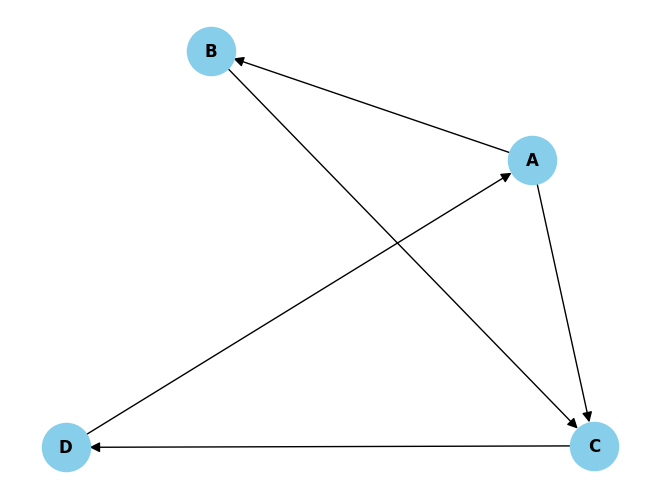

In [6]:
#Drawing and Visualizing Your GraphTo see your graph layout visually, use nx.draw() tied into Matplotlib
# Define a structural layout for node positions
# Other options: shell_layout, circular_layout, random_layout
pos = nx.spring_layout(G)

# Draw the layout
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=1200, font_weight="bold", arrowsize=15)

# Render window
plt.show()


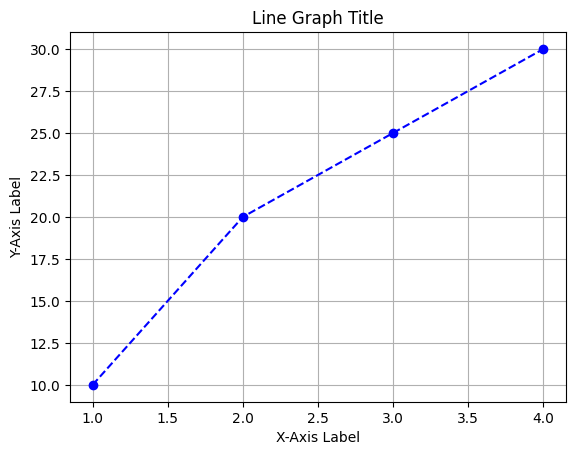

In [8]:
# The Anatomy of a Plot (Basic Line Graph)The standard setup to plot arrays or lists, add titles, and show the window
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = [10, 20, 25, 30]

plt.plot(x, y, color='blue', linestyle='--', marker='o') # Style line
plt.title("Line Graph Title")
plt.xlabel("X-Axis Label")
plt.ylabel("Y-Axis Label")
plt.grid(True)  # Add background grid lines

plt.show()      # Opens visual window


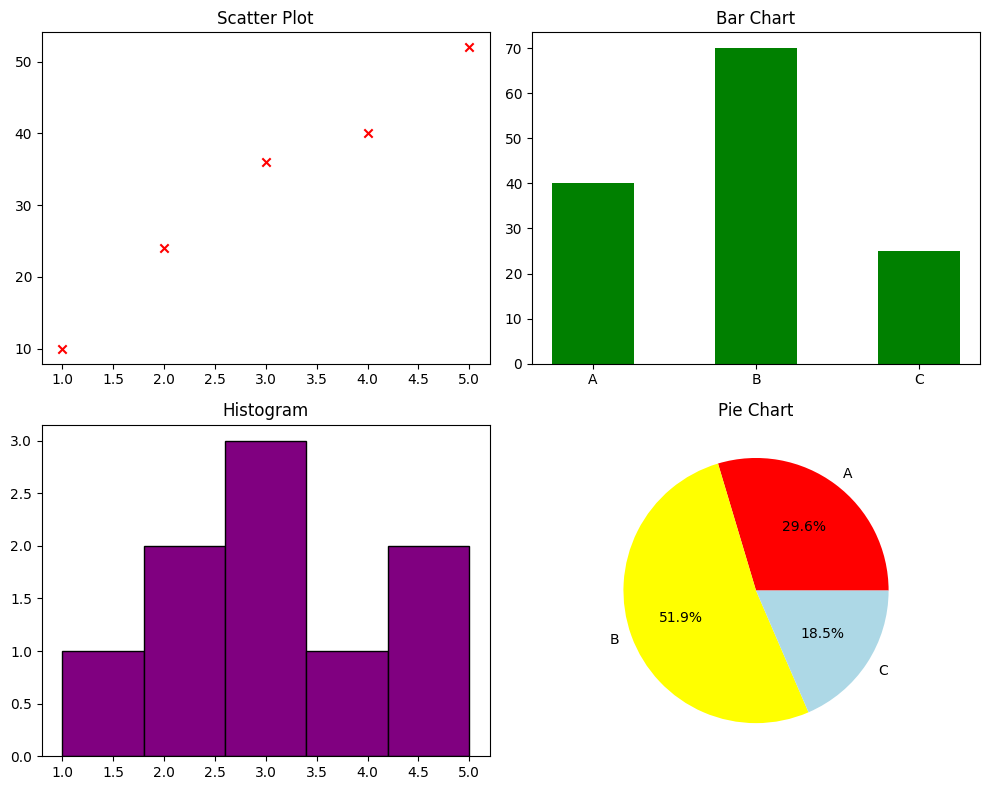

In [11]:
import matplotlib.pyplot as plt

# Sample data for scatter plot
x = [1, 2, 3, 4, 5]
y = [10, 24, 36, 40, 52]

# Sample data for bar and pie chart
categories = ['A', 'B', 'C']
values = [40, 70, 25]

# Sample data for histogram
data = [1, 2, 2, 3, 3, 3, 4, 5, 5]

# Create a 2x2 grid window with custom size
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# 1. Top-Left: Scatter Plot
axs[0, 0].scatter(x, y, color='red', marker='x')
axs[0, 0].set_title("Scatter Plot")

# 2. Top-Right: Bar Chart
axs[0, 1].bar(categories, values, color='green', width=0.5)
axs[0, 1].set_title("Bar Chart")

# 3. Bottom-Left: Histogram
axs[1, 0].hist(data, bins=5, color='purple', edgecolor='black')
axs[1, 0].set_title("Histogram")

# 4. Bottom-Right: Pie Chart
axs[1, 1].pie(values, labels=categories, autopct='%1.1f%%', colors=['red', 'yellow', 'lightblue'])
axs[1, 1].set_title("Pie Chart")

# Magic command: Adjust spacing automatically to completely stop overlap
plt.tight_layout()

# Show the combined window
plt.show()


<BarContainer object of 3 artists>

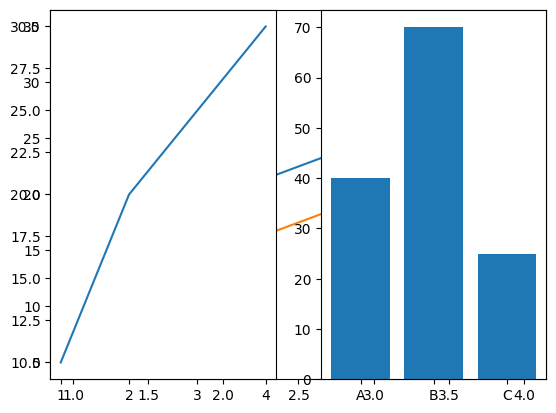

In [10]:
#Handling Multiple Plots (Legends & Subplots)
# Multi-line plot with a Legend
plt.plot(x, y, label="Dataset 1")
plt.plot(x, [5, 15, 20, 35], label="Dataset 2")
plt.legend(loc="upper left") # Renders the label box

# Subplots (Separate side-by-side graphs in one window)
# plt.subplots(rows, columns, current_plot_index)
plt.subplot(1, 2, 1)
plt.plot(x, y)       # Left graph

plt.subplot(1, 2, 2)
plt.bar(categories, values) # Right graph
